Import bibliotek

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option('display.float_format', '{:,.2f}'.format)

Załadowanie danych

In [29]:
df = pd.read_csv(r"data\sales_random.csv")

Pierwsze 5 obserwacji

In [30]:
df.head()

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
0,253422,146510_8.0105.29_BUD.58_LOK,"1,455,000.00","26,711.95",10,2,mieszkalna,PLN,54.47,2025-12-19,Ulica Stanisława Dubois 9,Warszawa
1,238130,146510_8.0609.17_BUD.1_LOK,"766,746.00","16,200.00",1,3,mieszkalna,PLN,47.33,2025-12-18,Ulica Górnośląska 9/11,Warszawa
2,253423,146510_8.0503.5_BUD.32_LOK,"1,227,869.00","14,139.44",5,4,mieszkalna,PLN,86.84,2025-12-17,Ulica Wilcza 56,Warszawa
3,238294,146515_8.0402.154_BUD.1_LOK,"623,000.00","12,874.56",1,2,mieszkalna,PLN,48.39,2025-12-16,Ulica Gen. Władysława Sikorskiego 67A,Warszawa
4,247472,146510_8.0609.17_BUD.52_LOK,"765,693.00","17,110.46",2,2,mieszkalna,PLN,44.75,2025-12-16,Ulica Górnośląska 9/11,Warszawa


Informacje na temat zbioru

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_rcn_id    10000 non-null  int64  
 1   name           10000 non-null  object 
 2   amount         10000 non-null  float64
 3   amount_sqm     10000 non-null  float64
 4   floor_number   10000 non-null  int64  
 5   rooms_number   10000 non-null  int64  
 6   type           10000 non-null  object 
 7   currency       10000 non-null  object 
 8   size           10000 non-null  float64
 9   creation_date  10000 non-null  object 
 10  invest_name    10000 non-null  object 
 11  invest_city    10000 non-null  object 
dtypes: float64(3), int64(3), object(6)
memory usage: 937.6+ KB


Licza unikatowych wartości w kolumnie 'type'

In [33]:
df['type'].value_counts()

type
mieszkalna    10000
Name: count, dtype: int64

Minimalna data

In [34]:
df['creation_date'].min()


'2016-11-28'

Maksymalna data

In [35]:
df['creation_date'].max()

'2025-12-19'

Statystyki zbiory na cechach numerycznych

In [36]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"268,993.56","863,660.17","16,195.65",3.89,2.66,53.42
std,"218,909.17","485,118.57","4,435.70",2.40,1.04,23.06
min,"52,577.00","115,000.00","3,246.33",0.00,0.00,20.04
25%,"241,633.75","583,845.00","13,254.77",2.00,2.00,38.27
50%,"247,352.50","733,000.00","15,235.31",3.00,3.00,47.40
75%,"252,903.25","998,669.50","18,001.28",5.00,3.00,62.73
max,"2,274,881.00","9,000,000.00","58,433.97",38.00,9.00,299.50


Obserwacja z maksymalna ceną za m2

In [37]:
df[df['amount_sqm']==df['amount_sqm'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
4009,220942,146505_8.0305.1077_BUD.87_LOK,"9,000,000.00","58,433.97",5,0,mieszkalna,PLN,154.02,2022-11-29,Ulica Iwicka 7,Warszawa


Obserwacje z maksymalna ceną

In [38]:
df[df['amount']==df['amount'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
4009,220942,146505_8.0305.1077_BUD.87_LOK,"9,000,000.00","58,433.97",5,0,mieszkalna,PLN,154.02,2022-11-29,Ulica Iwicka 7,Warszawa


Obserwacja z maksymalna powierzchnią

In [39]:
df[df['size']==df['size'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
6790,249439,146511_8.0923.20_BUD.2_LOK,"2,430,000.00","8,113.52",1,7,mieszkalna,PLN,299.50,2025-08-29,Ulica Zygmunta Jórskiego 47,Warszawa


Usunięcie wartości odstających na podstawie kryterium półtorakrotności rozstępu międzykwartylowego (IQR)

In [40]:
kolumny = ['amount','amount_sqm','size']
for i in kolumny:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[i] >= Q1 - 1.5*IQR) & (df[i] <= Q3 + 1.5*IQR)]

df = df = df[df['rooms_number'] != 0]

In [41]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size
count,"8,801.00","8,801.00","8,801.00","8,801.00","8,801.00","8,801.00"
mean,"263,332.58","750,560.67","15,399.09",3.85,2.58,49.15
std,"188,339.65","256,742.90","2,945.00",2.28,0.88,14.98
min,"52,577.00","205,950.00","6,604.75",0.00,1.00,20.04
25%,"241,782.00","566,100.41","13,187.55",2.00,2.00,37.89
50%,"247,452.00","699,000.00","14,955.17",3.00,2.00,46.00
75%,"252,945.00","882,450.00","17,283.49",5.00,3.00,59.53
max,"2,274,881.00","1,620,000.00","24,166.51",18.00,6.00,94.12


Rozkład mieszkań w podziale na liczbę pokoi

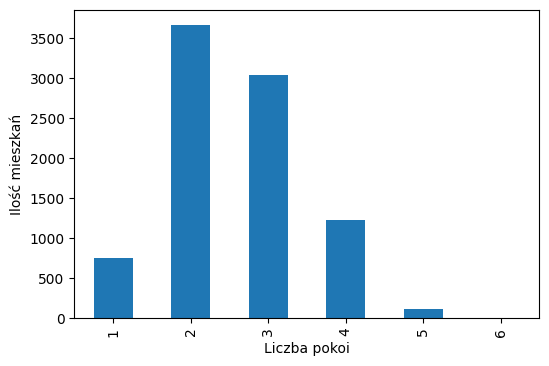

rooms_number
2    3674
3    3039
4    1221
1     749
5     117
6       1
Name: count, dtype: int64

In [42]:
df['rooms_number'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.xlabel('Liczba pokoi')
plt.ylabel('Ilość mieszkań')
plt.show()
df["rooms_number"].value_counts()

Rozkład mieszkań w podziale na piętro

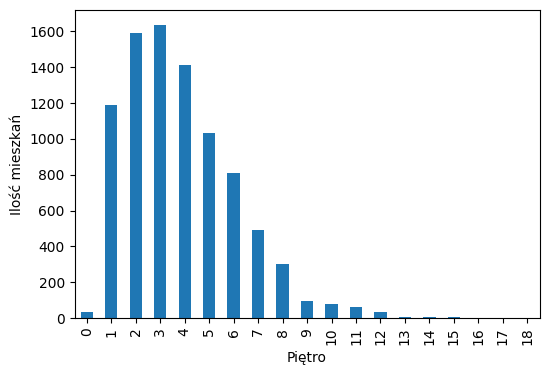

floor_number
3     1638
2     1594
4     1410
1     1190
5     1035
6      808
7      493
8      304
9       96
10      79
11      64
0       36
12      33
15       6
14       6
13       5
17       2
16       1
18       1
Name: count, dtype: int64

In [43]:
df['floor_number'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.xlabel('Piętro')
plt.ylabel('Ilość mieszkań')
plt.show()
df["floor_number"].value_counts()

Rozkład rozmiaru mieszkań

Text(0.5, 1.0, 'Rozkład rozmiaru mieszkań')

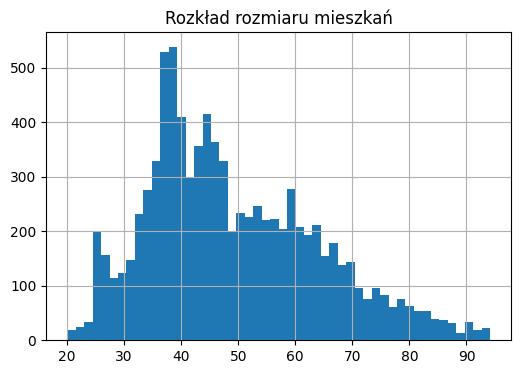

In [44]:
plt.figure(figsize=(6,4))
df["size"].hist(bins=50)
plt.title('Rozkład rozmiaru mieszkań')

Rozkład ceny za m2

Text(0.5, 1.0, 'Rozkład ceny za m2')

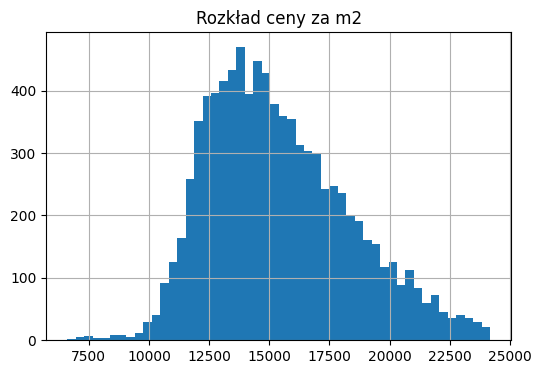

In [45]:
plt.figure(figsize=(6,4))
df["amount_sqm"].hist(bins=50)
plt.title('Rozkład ceny za m2')

In [46]:
round(df['amount_sqm'].mean(),2)


15399.09

In [47]:
round(df['amount_sqm'].median(),2)

14955.17

Średnie:
-rozmiar w podziale na liczbę pokoi
-cena za m2 w podziale na liczbę pokoi
-cena za m2 w podziale na piętro

In [48]:
gb = df.groupby('rooms_number')['size'].mean()
print(gb)
gb = df.groupby('rooms_number')['amount_sqm'].mean()
print(gb)
gb = df.groupby('floor_number')['amount_sqm'].mean()
print(gb)


rooms_number
1   30.77
2   40.24
3   55.43
4   68.70
5   79.18
6   86.20
Name: size, dtype: float64
rooms_number
1   16,800.39
2   15,636.44
3   15,166.12
4   14,533.97
5   14,089.20
6   11,357.31
Name: amount_sqm, dtype: float64
floor_number
0    15,117.09
1    15,246.10
2    15,208.48
3    15,394.38
4    15,389.57
5    15,452.43
6    15,652.02
7    15,620.51
8    15,426.32
9    15,990.44
10   16,377.31
11   15,630.38
12   14,206.72
13   18,982.75
14   15,277.32
15   16,735.06
16   12,088.00
17   18,950.67
18   17,062.49
Name: amount_sqm, dtype: float64


Wykres pudełkowy: cena za m2 w podziale na piętro

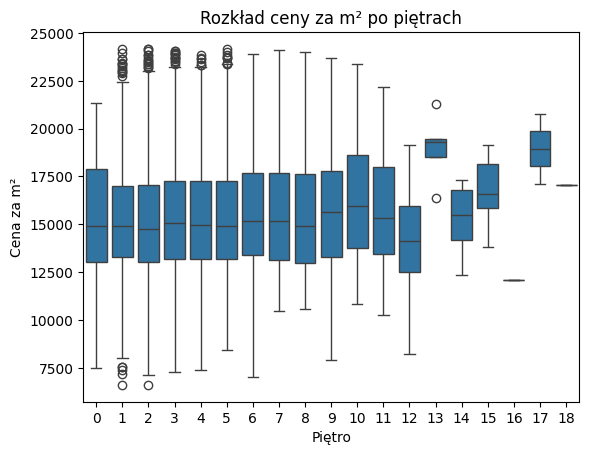

In [49]:
sns.boxplot(x='floor_number', y='amount_sqm', data=df)
plt.xlabel('Piętro')
plt.ylabel('Cena za m²')
plt.title('Rozkład ceny za m² po piętrach')
plt.show()

Sprzedaż mieszkań w czasie

Text(0.5, 1.0, 'Sprzedaż w czasie')

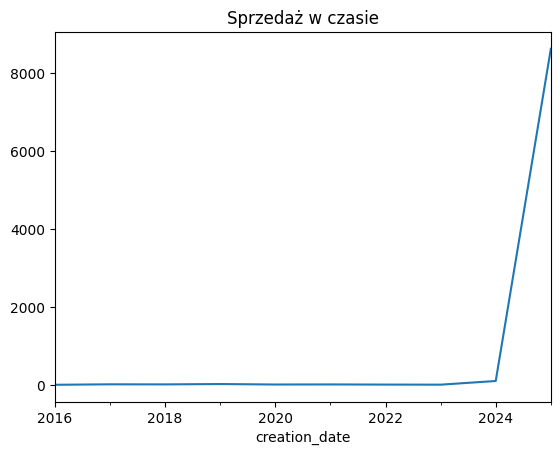

In [50]:
df['creation_date'] = pd.to_datetime(df['creation_date'])
df.groupby(df['creation_date'].dt.to_period('Y')).size().plot()
plt.title('Sprzedaż w czasie')

Dodanie kolumn miesiąc i rok

In [51]:
df['month'] = df['creation_date'].dt.month
df['year'] = df['creation_date'].dt.year
monthly_counts = df.groupby(['year','month']).size()

Ceny m2 w perspektywie czasu

<Axes: xlabel='creation_date'>

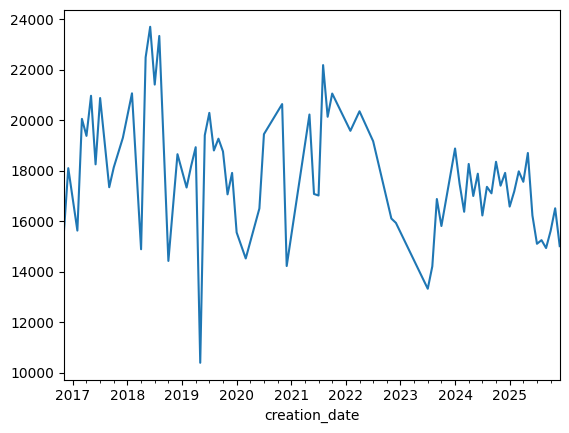

In [52]:
df.groupby(df['creation_date'].dt.to_period('M'))['amount_sqm'].mean().plot()

In [53]:
df.groupby(df['creation_date'].dt.to_period('M'))['amount_sqm'].mean().sort_values()

creation_date
2019-05   10,388.22
2023-07   13,320.63
2023-08   14,207.65
2020-12   14,220.71
2018-10   14,422.44
             ...   
2018-07   21,407.72
2021-08   22,179.10
2018-05   22,484.67
2018-08   23,333.33
2018-06   23,696.68
Freq: M, Name: amount_sqm, Length: 75, dtype: float64

In [58]:
df['creation_date'].dt.year.value_counts().sort_index()

creation_date
2016       3
2017      15
2018      13
2019      22
2020      10
2021      12
2022       8
2023       6
2024     100
2025    8612
Name: count, dtype: int64

<Axes: xlabel='creation_date'>

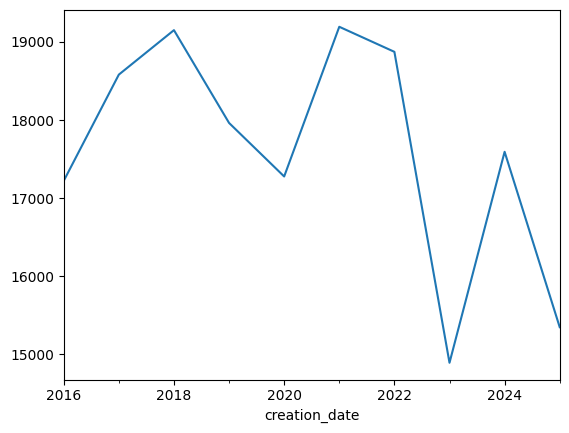

In [54]:
df.groupby(df['creation_date'].dt.to_period('Y'))['amount_sqm'].mean().plot()

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8801 entries, 1 to 9999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sale_rcn_id    8801 non-null   int64         
 1   name           8801 non-null   object        
 2   amount         8801 non-null   float64       
 3   amount_sqm     8801 non-null   float64       
 4   floor_number   8801 non-null   int64         
 5   rooms_number   8801 non-null   int64         
 6   type           8801 non-null   object        
 7   currency       8801 non-null   object        
 8   size           8801 non-null   float64       
 9   creation_date  8801 non-null   datetime64[ns]
 10  invest_name    8801 non-null   object        
 11  invest_city    8801 non-null   object        
 12  month          8801 non-null   int32         
 13  year           8801 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(3), object(5)
memory usage:

In [56]:
cpi = pd.read_csv(r"data/inflacja_prepared.csv", index_col=0).reset_index(drop=True)

In [57]:
cpi.head()

,Rok,Miesiąc,Wartość,date
0,2025,1,4.90,2025-01-01
1,2025,2,4.90,2025-02-01
2,2025,3,4.90,2025-03-01
3,2025,4,4.30,2025-04-01
4,2025,5,4.00,2025-05-01


In [29]:
dfp = df.merge(
    cpi[["Rok", "Miesiąc", "Wartość"]],
    left_on=["year", "month"],
    right_on=["Rok", "Miesiąc"],
    how="left"
).drop(columns=["Rok", "Miesiąc"])

In [30]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sale_rcn_id    2124 non-null   int64         
 1   name           2124 non-null   object        
 2   amount         2124 non-null   float64       
 3   amount_sqm     2124 non-null   float64       
 4   floor_number   2124 non-null   int64         
 5   rooms_number   2124 non-null   int64         
 6   type           2124 non-null   object        
 7   currency       2124 non-null   object        
 8   size           2124 non-null   float64       
 9   creation_date  2124 non-null   datetime64[ns]
 10  invest_name    2124 non-null   object        
 11  invest_city    2124 non-null   object        
 12  month          2124 non-null   int32         
 13  year           2124 non-null   int32         
 14  Wartość        2124 non-null   float64       
dtypes: datetime64[ns](1),

In [31]:
dfp = dfp[['amount','amount_sqm','floor_number','rooms_number','size','month','year','Wartość']]

In [32]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amount        2124 non-null   float64
 1   amount_sqm    2124 non-null   float64
 2   floor_number  2124 non-null   int64  
 3   rooms_number  2124 non-null   int64  
 4   size          2124 non-null   float64
 5   month         2124 non-null   int32  
 6   year          2124 non-null   int32  
 7   Wartość       2124 non-null   float64
dtypes: float64(4), int32(2), int64(2)
memory usage: 116.3 KB


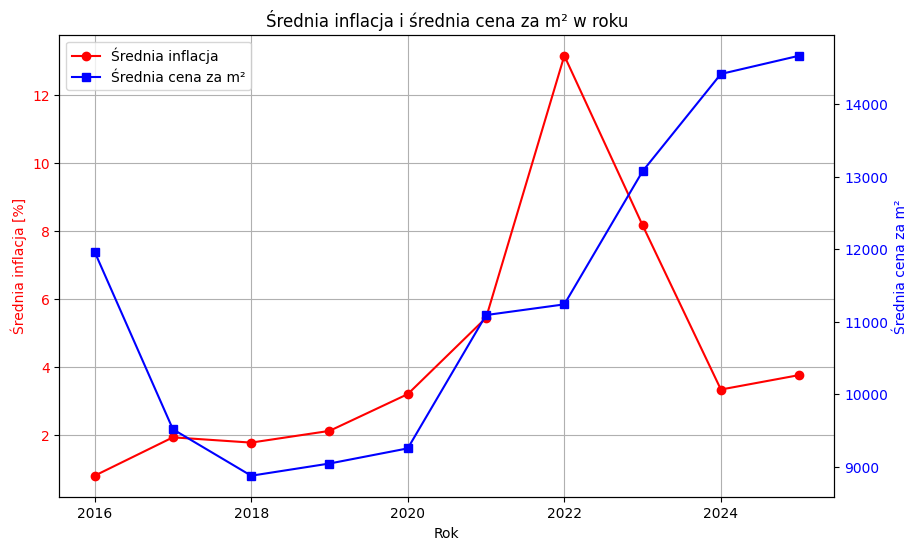

In [33]:
# Grupowanie po roku i liczenie średnich
yearly = dfp.groupby("year").agg({
    "Wartość": "mean",      # średnia inflacja
    "amount_sqm": "mean"    # średnia cena za m2
}).reset_index()

# Tworzymy wykres z podwójną osią Y
fig, ax1 = plt.subplots(figsize=(10,6))

# Linia średniej inflacji
color = 'red'
ax1.set_xlabel('Rok')
ax1.set_ylabel('Średnia inflacja [%]', color=color)
ax1.plot(yearly['year'], yearly['Wartość'], color=color, marker='o', label='Średnia inflacja')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Druga oś Y dla średniej ceny za m²
ax2 = ax1.twinx()
color = 'blue'
ax2.set_ylabel('Średnia cena za m²', color=color)
ax2.plot(yearly['year'], yearly['amount_sqm'], color=color, marker='s', label='Średnia cena za m²')
ax2.tick_params(axis='y', labelcolor=color)

# Dodanie legendy
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Średnia inflacja i średnia cena za m² w roku')
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [35]:
X = dfp.drop(columns=['amount'])
y = dfp['amount']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=40)


In [37]:
lin = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=40)

models = [("Linear Regression", lin), ("Random Forest", rf)]
for name, model in models:
    model.fit(X_train, y_train)
    
for name, model in models:
    
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    rmse_train = mean_squared_error(y_train, y_pred_train, squared=False)
    rmse_test  = mean_squared_error(y_test, y_pred_test, squared=False)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test, y_pred_test)
    
    print(f"=== {name} ===")
    print(f"Train RMSE: {rmse_train:.2f}, R²: {r2_train:.4f}")
    print(f"Test  RMSE: {rmse_test:.2f}, R²: {r2_test:.4f}\n")

=== Linear Regression ===
Train RMSE: 57349.24, R²: 0.9390
Test  RMSE: 51666.12, R²: 0.9435

=== Random Forest ===
Train RMSE: 6203.95, R²: 0.9993
Test  RMSE: 12961.16, R²: 0.9964



!Kontynuacja...